In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "1" 

from decoder_quant import (
    mask_decoder_monkey_patch, 
    inference_image,
    re_cal_attn,
    TwoWayTransformerObserver,
) 
from utils import get_activation_boxplot, to_numpy
from segment_anything import SamPredictor, sam_model_registry
import matplotlib.pyplot as plt
from quant_utils import SignProcessor, DoNothingProcessor, AttnBasedProcessor
from segment_anything.modeling.transformer import TwoWayAttentionBlock, TwoWayTransformer, Attention



/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/segment_anything/modeling/tiny_vit_sam.py:662: UserWarning: Overwri

In [2]:

model_type = 'vit_l'
checkpoint_path= './pretrained_checkpoint/sam_hq_vit_l.pth'
sam = sam_model_registry[model_type](checkpoint=checkpoint_path).to('cuda')


predictor = SamPredictor(sam)
processor = AttnBasedProcessor('attn') 
# processor = DoNothingProcessor('attn') 
# processor = SignProcessor('attn') 
processor.calibrate(
    predictor=predictor, 
    modules=(TwoWayTransformer),
    num_samples=16,
)
mask_decoder_monkey_patch(predictor.model, processor, n_bits=4)


<All keys matched successfully>
------------------------------ valid --------------------------------
--->>> valid  dataset  0 / 1   DIS5K-VD <<<---
-im- DIS5K-VD ./data/DIS5K/DIS-VD/im :  470
-gt- DIS5K-VD ./data/DIS5K/DIS-VD/gt :  470
valid_dataloader len: 470


Calibrating:   0%|          | 0/16 [00:00<?, ?it/s]/home/chauht2/SAM_Quantization/.venv/lib/python3.10/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Calibrating: 100%|██████████| 16/16 [00:10<00:00,  1.59it/s]

Processing module: cross_attn_token_to_image.q_proj
Processing module: cross_attn_token_to_image.k_proj
Processing module: cross_attn_token_to_image.v_proj
Processing module: cross_attn_token_to_image.out_proj
Processing module: cross_attn_image_to_token.q_proj
Processing module: cross_attn_image_to_token.k_proj
Processing module: cross_attn_image_to_token.v_proj
Processing module: cross_attn_image_to_token.out_proj
Processing module: cross_attn_token_to_image.q_proj
Processing module: cross_attn_token_to_image.k_proj
Processing module: cross_attn_token_to_image.v_proj
Processing module: cross_attn_token_to_image.out_proj
Processing module: cross_attn_image_to_token.q_proj
Processing module: cross_attn_image_to_token.k_proj
Processing module: cross_attn_image_to_token.v_proj
Processing module: cross_attn_image_to_token.out_proj
Processing module: final_attn_token_to_image.q_proj
Processing module: final_attn_token_to_image.k_proj
Processing module: final_attn_token_to_image.v_proj
Proc

In [3]:
predictor.model.mask_decoder

MaskDecoderHQ(
  (transformer): TwoWayTransformerObserver(
    (layers): ModuleList(
      (0-1): 2 x TwoWayAttentionBlockObserver(
        (self_attn): AttentionObserver(
          (q_proj): Linear(in_features=256, out_features=256, bias=True)
          (k_proj): Linear(in_features=256, out_features=256, bias=True)
          (v_proj): Linear(in_features=256, out_features=256, bias=True)
          (out_proj): Linear(in_features=256, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (cross_attn_token_to_image): AttentionObserver(
          (q_proj): W8A8Linear(256, 128, bias=True, weight_quant=per_channel, act_quant=per_token, output_quant=None)
          (k_proj): W8A8Linear(256, 128, bias=True, weight_quant=per_channel, act_quant=per_token, output_quant=None)
          (v_proj): W8A8Linear(256, 128, bias=True, weight_quant=per_channel, act_quant=per_token, output_quant=None)
          (out_proj): W8A8Linear(128, 256, 

0
(1024, 1024, 3)


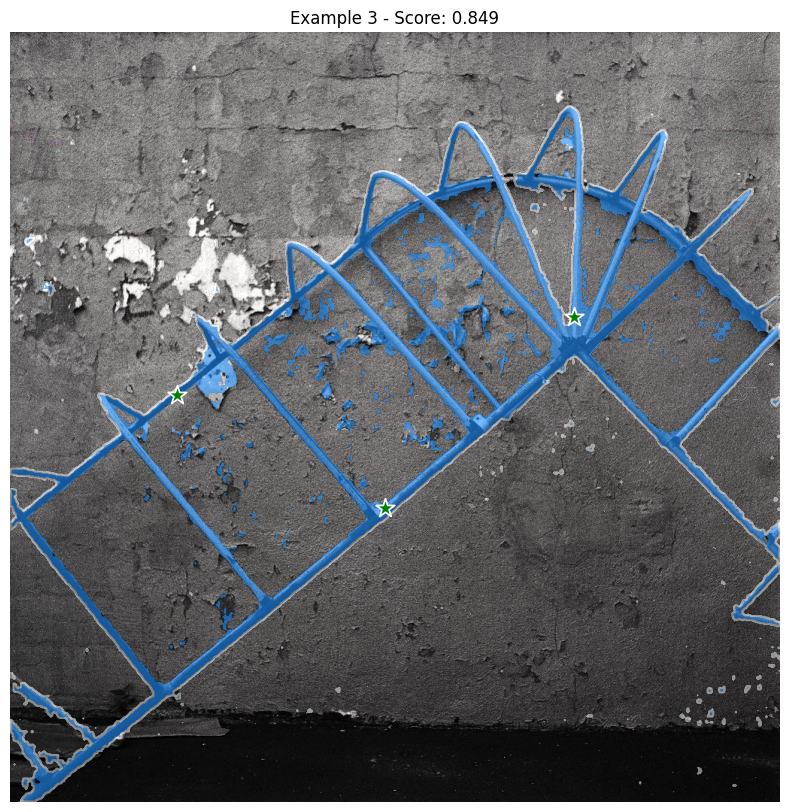

(array([[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]]],
       shape=(1, 1024, 1024)),
 array([0.8487088], dtype=float32),
 array([[[ -7.6087193 ,  -7.004184  ,  -7.3377333 , ...,  -8.231606  ,
          -11.28983   ,  -9.747831  ],
         [ -6.6869197 ,  -6.283544  ,  -6.955934  , ...,  -8.105553  ,
          -11.532211  ,  -9.218201  ],
         [-10.805557  ,  -9.323003  , -11.369234  , ...,  -6.956453  ,
           -8.525549  ,  -8.497651  ],
         ...,
         [ -5.473838  ,  -2.288138  ,  -4.761818  , ...,  -4.048579  ,
           -5.0109477 ,  -5.590649  ],
         [ -4.6195536 ,  -1.8013096 ,  -5.5425944 , ...,  -0.08374119,
           -3.355271  ,  -3.1531672 ],
     

In [4]:
# results = inference_image(predictor, image_dir='./input_imgs/', example_idx=3, show_image=True)
# for i in range(5):
print(len(TwoWayTransformerObserver.attention_score['p2i_attn']))
inference_image(predictor, image_dir='./input_imgs/', example_idx=3, show_image=True)

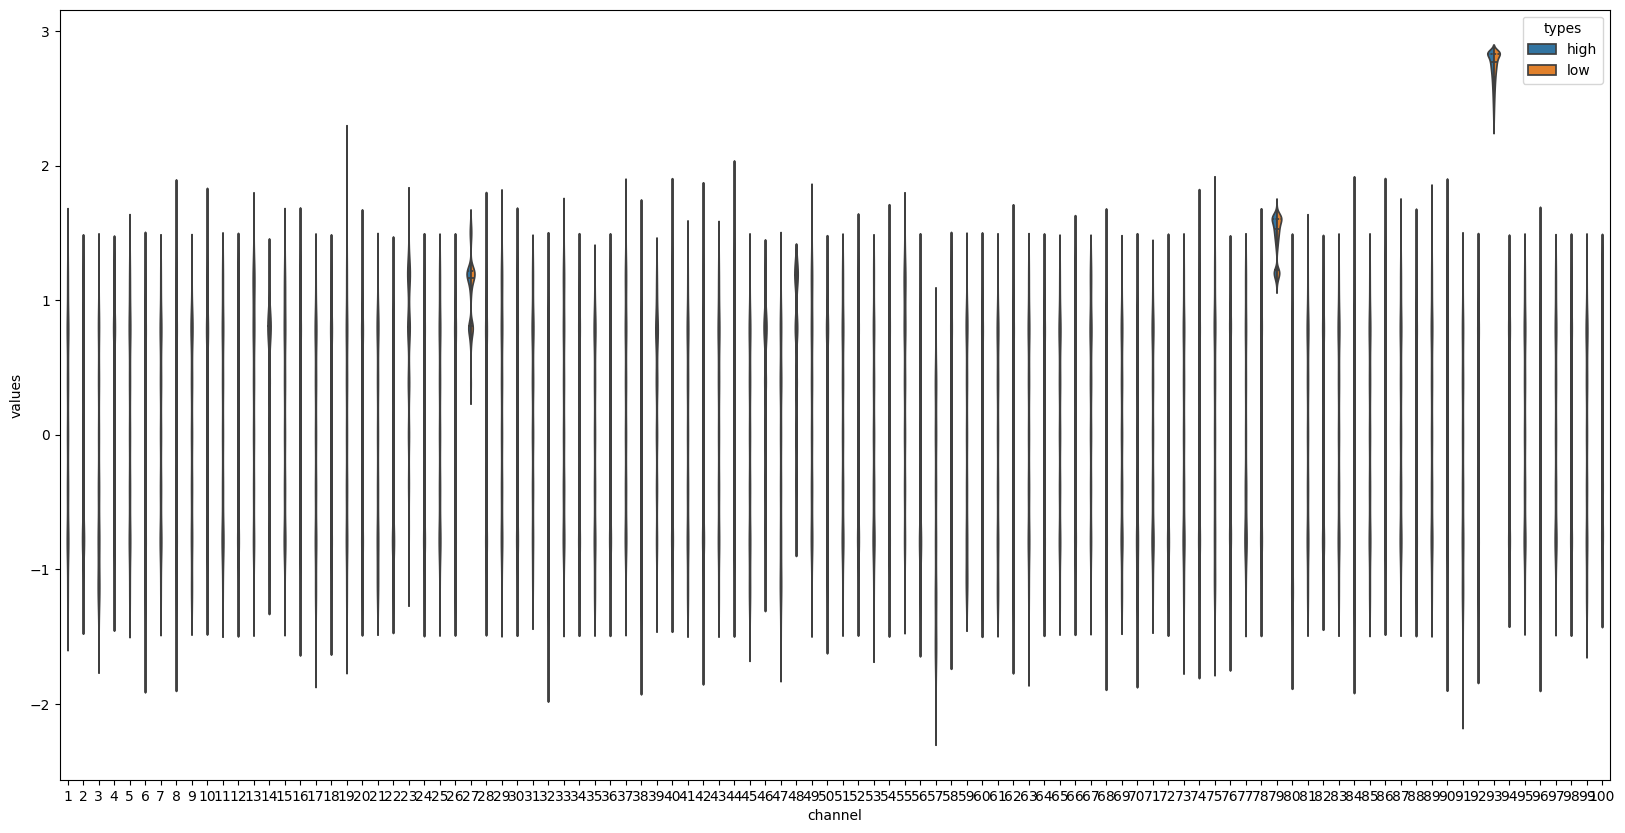

In [5]:
pre_i = TwoWayTransformerObserver.attention_score["p2i_k_pre"][0]
pre_p  = TwoWayTransformerObserver.attention_score["p2i_q_pre"][0]
fig, ax= plt.subplots(1,1, figsize=(20,10))

get_activation_boxplot(high_activations=pre_i, low_activations=pre_i, ax=ax, offset=150, max_channels=100,token_wise=False)



In [6]:
weights = TwoWayTransformerObserver.extract_weights(predictor.model)

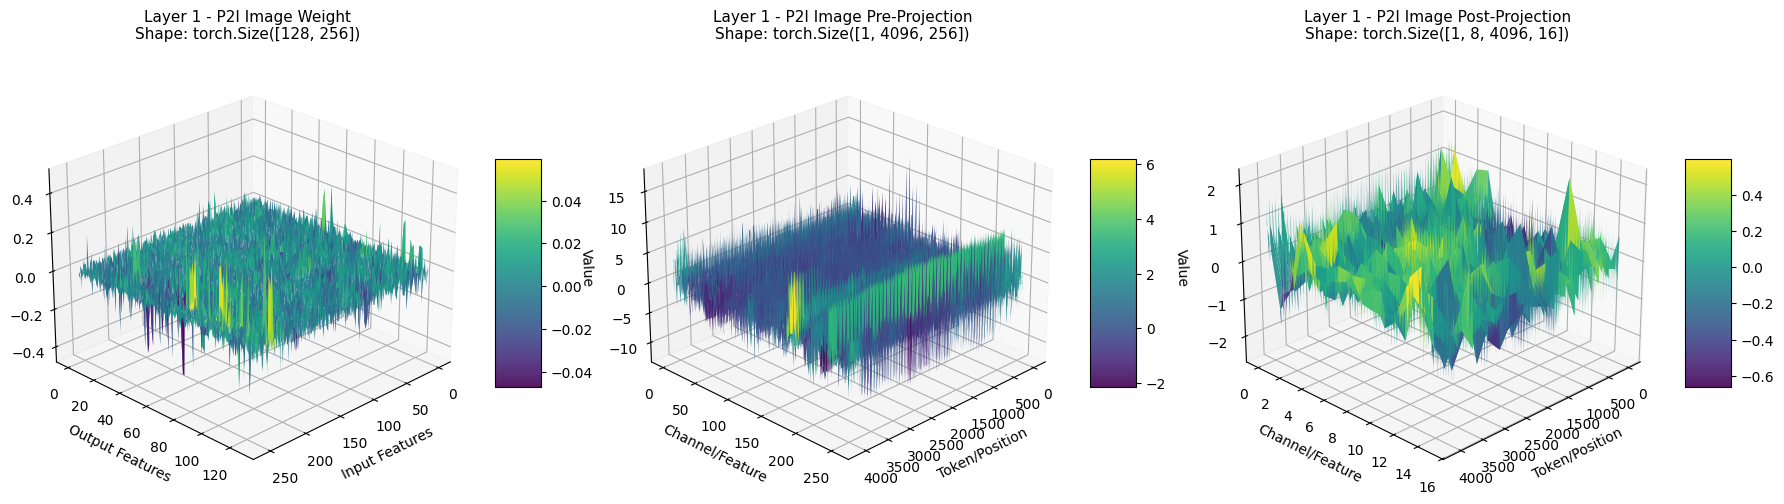

In [9]:
from decoder_quant import TwoWayTransformerObserver
from utils import plot_weight_activation_comparison

# After running inference with decoder_quant.py

# Extract weights once
weights = TwoWayTransformerObserver.extract_weights(predictor.model)

# Get activations for layer 0, p2i (point-to-image) Q projection
layer_idx = 1
q_weight = TwoWayTransformerObserver.weights[f"p2i_k_w_layer{layer_idx}"]
q_pre = TwoWayTransformerObserver.attention_score["p2i_k_pre"][layer_idx]
q_post = TwoWayTransformerObserver.attention_score["p2i_k"][layer_idx]
# q_weight = TwoWayTransformerObserver.weights[f"final_k_w"]
# q_pre = TwoWayTransformerObserver.attention_score["final_k_pre"]
# q_post = TwoWayTransformerObserver.attention_score["final_k"]


# Plot side by side
fig = plot_weight_activation_comparison(
    weight=q_weight,
    activation_pre=q_pre,
    activation_post=q_post,
    title_prefix=f"Layer {layer_idx} - P2I Image",
    cmap='viridis',
    figsize=(18, 5),
    show_colorbar=True,
    abs_value=False
)
plt.show()

In [54]:
# n_heads = TwoWayTransformerObserver.attention_score['p2i_attn'][0].shape[1]
# fig, axes = plt.subplots(3,n_heads, figsize=(150,50))

# a= TwoWayTransformerObserver.attention_score['p2i_attn']
# # print(len(a))

# # print(a.shape)
# fig, axes = plt.subplots(5,n_heads, figsize=(150,90))
# for im in range(5):
#     for i in range(n_heads):
#         axes[im][i].imshow(TwoWayTransformerObserver.attention_score['p2i_attn'][0+2*im][:,i,:].mean(1).reshape(64,64).cpu().detach().numpy())

    
# # for i in range(n_heads):
# #     axes[1][i].imshow(TwoWayTransformerObserver.attention_score['p2i_attn'][1][:,i,:].mean(1).reshape(64,64).cpu().detach().numpy())

# # for i in range(n_heads):
# #     axes[2][i].imshow(TwoWayTransformerObserver.attention_score['final_attn'][:,i,:].mean(1).reshape(64,64).cpu().detach().numpy())


In [55]:
# q = TwoWayTransformerObserver.attention_score['p2i_q'][1]
# k = TwoWayTransformerObserver.attention_score['p2i_k'][1]
# n_heads = q.shape[1] 
# q = TwoWayTransformerObserver.attention_score['i2p_q'][0].permute(0,2,1,3).reshape(1,-1,128 )
# k = TwoWayTransformerObserver.attention_score['i2p_k'][0].permute(0,2,1,3).reshape(1,-1,128 )
# q = TwoWayTransformerObserver.attention_score['final_q'].permute(0,2,1,3).reshape(1,-1,128 )
# k = TwoWayTransformerObserver.attention_score['final_k'].permute(0,2,1,3).reshape(1, -1, 128)


# attn_map = re_cal_attn(q, k)
# print(attn_map.shape)

# fig, axes = plt.subplots(1,n_heads, figsize=(150,50))

# for i in range(n_heads):
    # axes[i].imshow(attn_map[:,i,:].mean(1).reshape(64,64).cpu().detach().numpy())

In [56]:
# q = TwoWayTransformerObserver.attention_score['i2p_q'][0].permute(0,2,1,3).reshape(1,-1,128 )
# k = TwoWayTransformerObserver.attention_score['i2p_k'][0].permute(0,2,1,3).reshape(1,-1,128 )

In [57]:
import torch
import torch.nn.functional as F

def cal_density(X:torch.Tensor, margin:float=0.9,independent_heads=True):
    if not independent_heads:
        X = X.mean(2, keepdim=True)

    # X = X.permute(0, 2, 1, 3)
    X = F.normalize(X, p=2, dim=-1)

    score_map =F.elu(X @ X.transpose(-1, -2)-margin,alpha=0 )
    # score_map = X @ X.transpose(-1, -2)
    print(score_map.shape)
    scores = score_map.mean(-1)
    return scores



# i2p_q = TwoWayTransformerObserver.attention_score['i2p_q'][1]
# i2p_k = TwoWayTransformerObserver.attention_score['i2p_k'][1]
# p2i_q = TwoWayTransformerObserver.attention_score['p2i_q'][1]

torch.Size([1, 8, 4096, 4096])


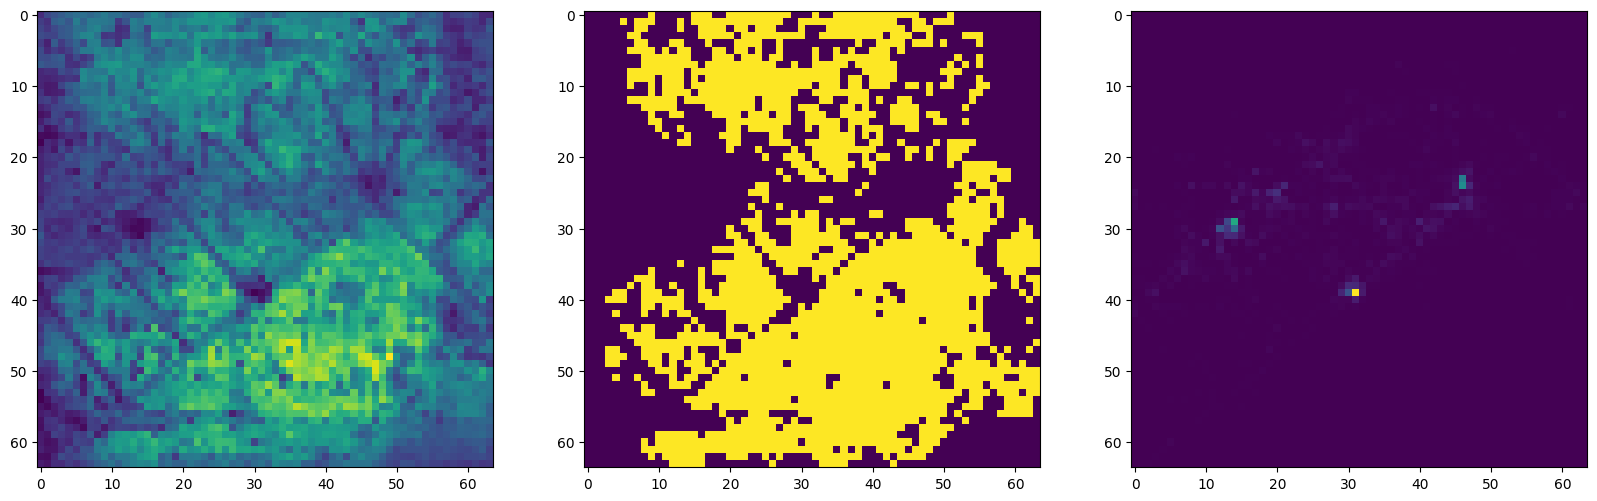

In [58]:
head=0
layer=1
p2i_q = TwoWayTransformerObserver.attention_score['p2i_q'][layer]
p2i_k = TwoWayTransformerObserver.attention_score['p2i_k'][layer]
scores = cal_density(p2i_k,margin=0.96)
score_map=scores.mean(1)
fig,ax=plt.subplots(1,3,figsize=(20,15))

ax[0].imshow(score_map.reshape(64,64).cpu().detach().numpy())
score_map=torch.where(score_map>score_map.mean(-1,keepdim=True),1,0)
ax[1].imshow(score_map.reshape(64,64).cpu().detach().numpy())
ax[2].imshow(TwoWayTransformerObserver.attention_score['p2i_attn'][layer][:,head,:].mean(1).reshape(64,64).cpu().detach().numpy())

torch.Size([1, 8, 4096, 4096])


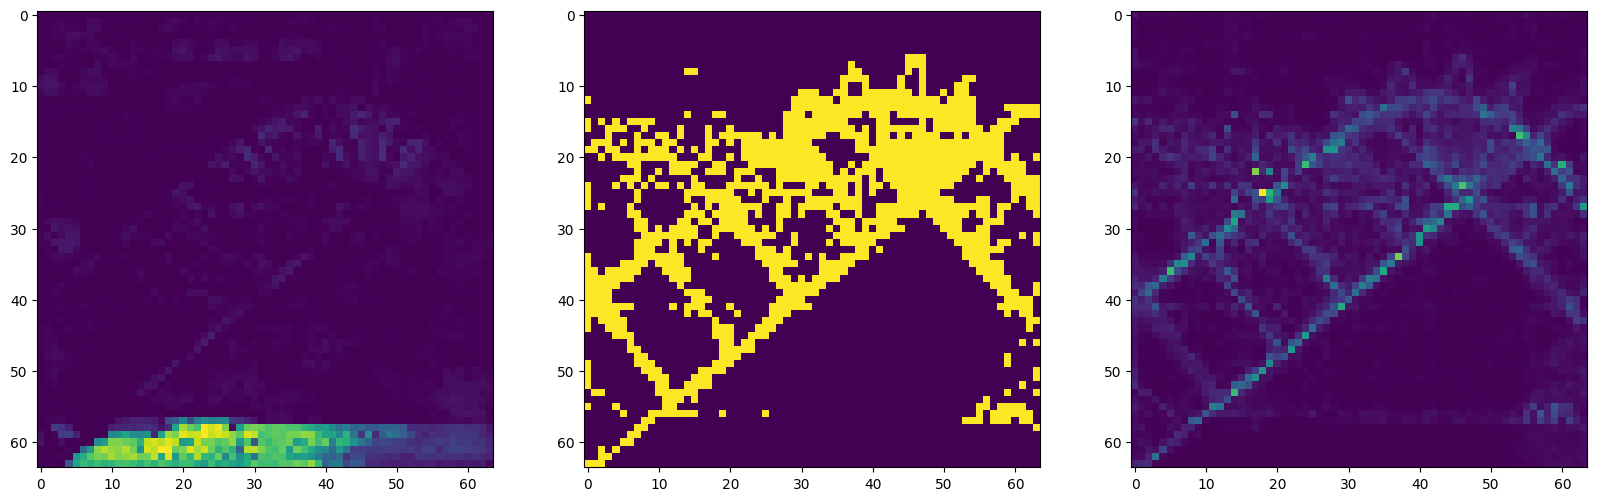

In [59]:

head=0
p2i_q = TwoWayTransformerObserver.attention_score['final_q']
p2i_k = TwoWayTransformerObserver.attention_score['final_k']
attn_map = TwoWayTransformerObserver.attention_score['final_attn'].mean(1).mean(1)

scores = cal_density(p2i_k,margin=0.96)

score_map=scores.mean(1)
fig,ax=plt.subplots(1,3,figsize=(20,15))


ax[0].imshow(score_map.reshape(64,64).cpu().detach().numpy())
# mask=torch.where(score_map>score_map.mean(-1,keepdim=True),1,0)
mask=torch.where(attn_map>attn_map.mean(-1,keepdim=True),1,0)

ax[1].imshow(mask.reshape(64,64).cpu().detach().numpy())
ax[2].imshow(attn_map.reshape(64,64).cpu().detach().numpy())

In [60]:


p2i_q =p2i_q.reshape(1, -1, 128)
p2i_k_high=p2i_k.permute(2,0,1,3)[mask.squeeze().nonzero()].squeeze(1).permute(1,0,2,3)
p2i_k_low=p2i_k.permute(2,0,1,3)[(1-mask).squeeze().nonzero()].squeeze(1).permute(1,0,2,3)
# diff =processor.stat['mask_decoder.transformer.final_attn_token_to_image']['diff']
# order =processor.stat['mask_decoder.transformer.final_attn_token_to_image']['order']

In [61]:
p2i_k_high.shape

torch.Size([1, 1111, 8, 16])

In [62]:
i2p_q = TwoWayTransformerObserver.attention_score['i2p_q'][1]
i2p_k = TwoWayTransformerObserver.attention_score['i2p_k'][1]
# attn_map = TwoWayTransformerObserver.attention_score['i2p_attn'].mean(1).mean(1)

In [63]:
i2p_k

tensor([[[[ 6.1109, -5.0924, -5.0924,  ...,  3.0554, -4.0739, -6.1109],
          [ 5.7217, -5.7217, -5.7217,  ...,  3.8144, -4.7680, -5.7217],
          [ 5.8853, -4.9044, -5.8853,  ...,  3.9235, -4.9044, -5.8853],
          ...,
          [ 6.7165, -3.8380, -5.7570,  ...,  5.7570, -4.7975, -5.7570],
          [ 5.8703, -3.9135, -6.8486,  ...,  4.8919, -4.8919, -3.9135],
          [ 5.3203, -7.4484, -6.3843,  ...,  5.3203, -3.1922, -5.3203]],

         [[ 5.2302, -4.1842, -6.2763,  ...,  6.2763,  4.1842, -4.1842],
          [ 4.3370, -4.3370, -7.5897,  ...,  5.4212,  5.4212, -3.2527],
          [ 5.0200, -5.0200, -5.0200,  ...,  6.0240,  4.0160, -5.0200],
          ...,
          [ 4.9362, -5.9234, -1.9745,  ...,  6.9107,  3.9490, -2.9617],
          [ 6.5838, -5.6433, -1.8811,  ...,  4.7027,  5.6433, -3.7622],
          [ 4.2379, -4.2379, -9.8885,  ...,  5.6506,  5.6506, -2.8253]],

         [[-6.4429,  4.2953, -7.5167,  ..., -3.2215,  2.1476, -3.2215],
          [-6.2934,  5.2445, -

In [64]:
# diff_new = torch.gather(diff.reshape(8,-1), index=order, dim=-1)
# p2i_k_high_reorder = torch.gather(p2i_k_high, index=order[None, None,...].expand(p2i_k_high.shape), dim=-1 )
# p2i_k_low_reorder = torch.gather(p2i_k_low, index=order[None, None,...].expand(p2i_k_low.shape), dim=-1 )

In [65]:
p2i_k.shape

torch.Size([1, 8, 4096, 16])

In [66]:
p2i_k_mean = p2i_k.mean(-2,keepdim=True).reshape(-1, 128)

In [67]:
p2i_k_mean.shape

torch.Size([1, 128])

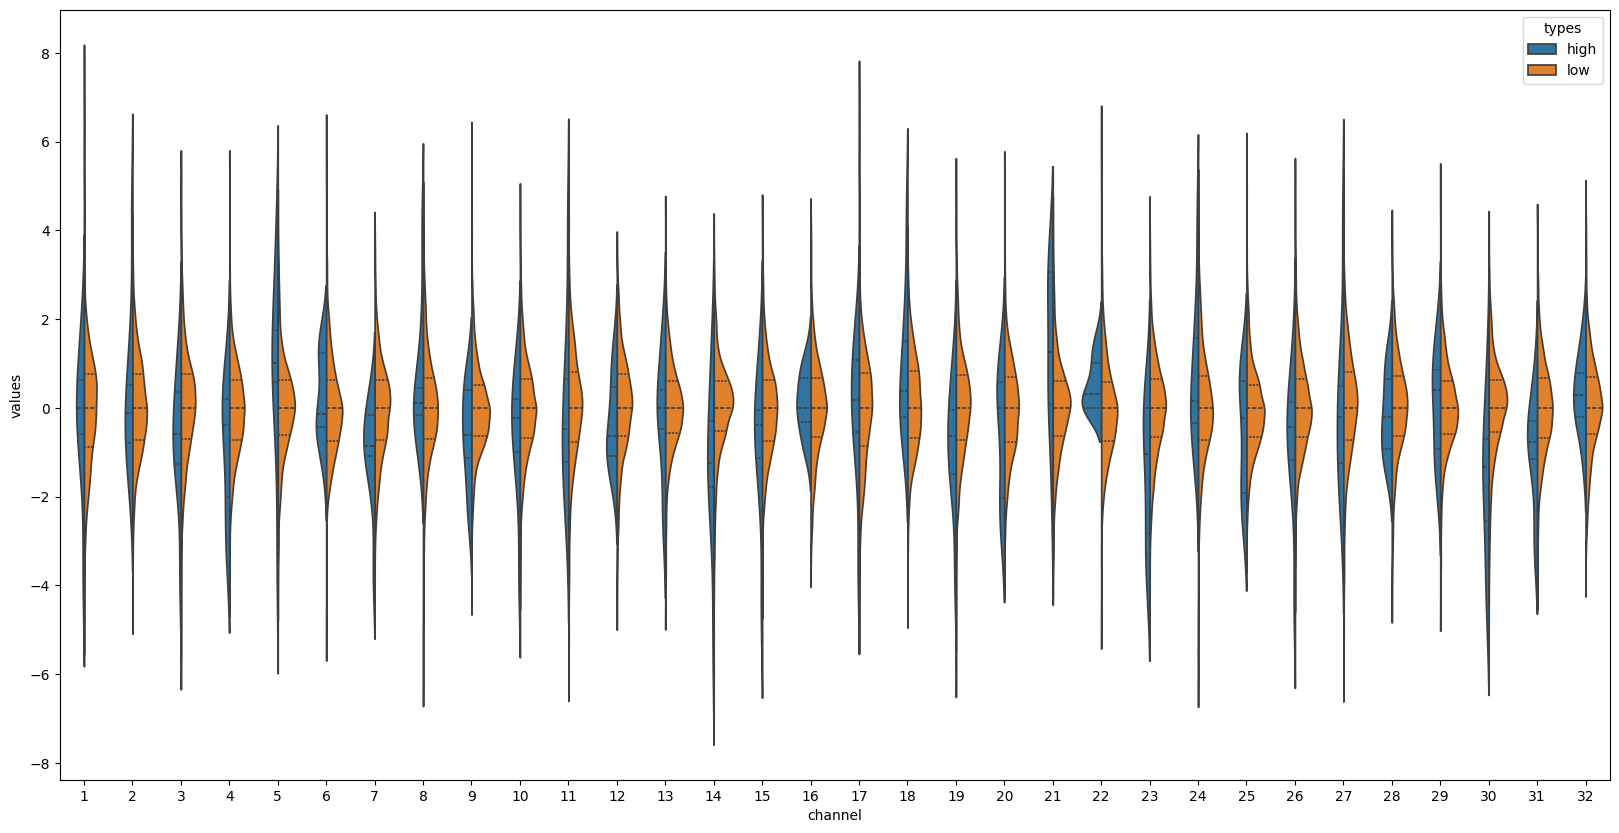

In [68]:
fig, ax= plt.subplots(1,1, figsize=(20,10))
# get_activation_boxplot(high_activations=p2i_k_high.reshape(-1,128), low_activations=p2i_k_low.reshape(-1,128), ax=ax, offset=0, max_channels=32,token_wise=False, diff=diff)
get_activation_boxplot(high_activations=p2i_q.reshape(-1,128)/2, low_activations=(p2i_k.reshape(-1,128))*2, ax=ax, offset=0, max_channels=32,token_wise=False)

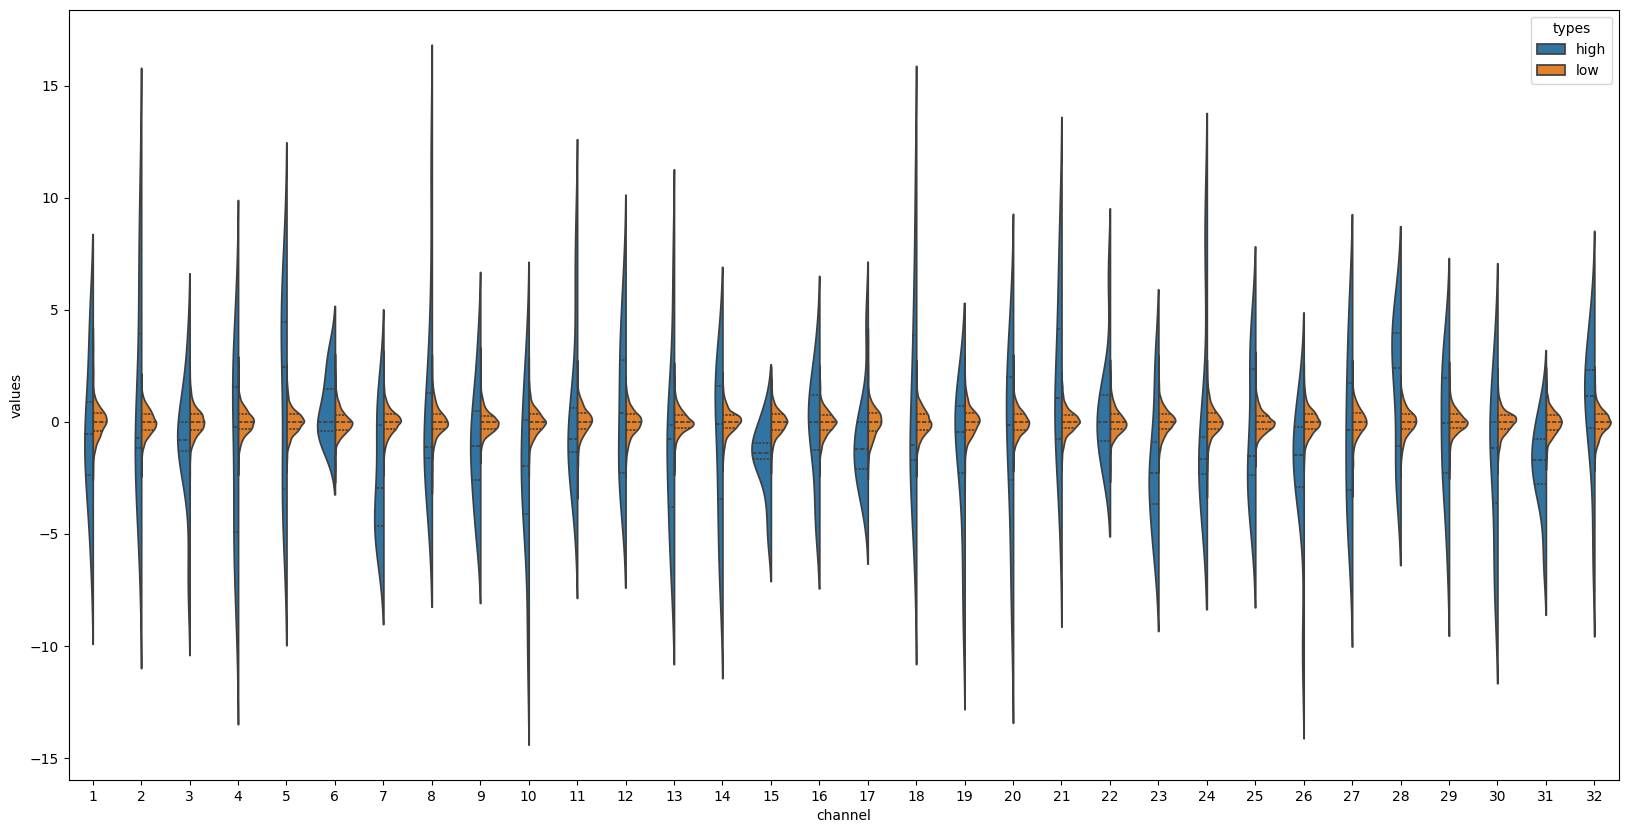

In [69]:
fig, ax= plt.subplots(1,1, figsize=(20,10))
# get_activation_boxplot(high_activations=p2i_k_high.reshape(-1,128), low_activations=p2i_k_low.reshape(-1,128), ax=ax, offset=0, max_channels=32,token_wise=False, diff=diff)
get_activation_boxplot(high_activations=p2i_q.reshape(-1,128), low_activations=(p2i_k.reshape(-1,128)), ax=ax, offset=96, max_channels=32,token_wise=False)
# get_activation_boxplot(high_activations=p2i_q.reshape(-1,128), low_activations=(p2i_k_high.reshape(-1,128)-p2i_k_mean), ax=ax, offset=0, max_channels=32,token_wise=False)
# get_activation_boxplot(high_activations=p2i_k_high.reshape(-1,128), low_activations=p2i_k_low.reshape(-1,128), ax=ax, offset=0, max_channels=32,token_wise=False, diff=diff_new.reshape(-1, 128))
# get_activation_boxplot(high_activations=p2i_k_high.reshape(-1,128), low_activations=p2i_k_low.reshape(-1,128), ax=ax, offset=0, max_channels=32,token_wise=False, diff=diff_new.reshape(-1, 128))
# get_activation_boxplot(high_activations=(i2p_q).reshape(-1,128), low_activations=(i2p_k).reshape(-1,128), ax=ax, offset=0, max_channels=32,token_wise=False)

In [70]:
# get_activation_boxplot(high_activations=p2i_q/2, low_activations=2*p2i_k_high, ax=ax, offset=0, max_channels=32,token_wise=False)
# get_activation_boxplot(high_activations=p2i_q/2, low_activations=2*p2i_k_low, ax=ax, offset=0, max_channels=32,token_wise=False)

In [65]:
TwoWayTransformerObserver.clear_dict()